In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, glob, scipy
from tqdm import tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives, egd, training
from jaxpm.painting import cic_paint, cic_read, compensate_cic, cic_paint_2d
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 128
mesh_per_dim = parts_per_dim

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# general
cosmo = vali_dict["cosmo"]
scales = vali_dict["scales"]

# particles
dm_poss = vali_dict["dm_poss"]
dm_vels = vali_dict["dm_vels"]

gas_poss = vali_dict["gas_poss"]
gas_vels = vali_dict["gas_vels"]

# masses
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=128,mesh=128.h5


In [5]:
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)
solve_ode = jax.jit(solve_ode, static_argnames=("nt", "training"))

In [6]:
checkpoint_dir = "/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints"

# pressure correction

In [7]:
d_hidden = 16
n_hidden = 6
checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/laced-sweep-21/checkpoint.jx"

In [8]:
pressure_model = ConditionedCNN(
    d_in=4,
    d_out=1,
    d_hidden=d_hidden,
    n_hidden=n_hidden,
    kernel_size=(3, 3, 3),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    use_residual=True,
)

pressure_model.load(checkpoint_file)

Checkpoint loaded from /global/u2/a/athomsen/flatiron/JaxPM/dev/apps/training/sweeps/128_cnn_v1/laced-sweep-21/checkpoint.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# final fields

In [9]:
i0 = 0
i1 = -1

# particle mesh
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
t0 = scales[i0]
ts = scales[i1]

def make_rho(dm_pos, gas_pos):
    rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos, dm_mass)
    rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, gas_mass)
    rho_tot = rho_dm + rho_gas

    return rho_dm, rho_gas, rho_tot

# PM
pm_res = solve_ode(y0, t0, [ts], gravity_model=None, pressure_model=None, tstep=scales, nt=1)
pm_dm_pos, pm_dm_vel, pm_gas_pos, pm_gas_vel = pm_res
pm_rho_dm, pm_rho_gas, pm_rho_tot = make_rho(pm_dm_pos, pm_gas_pos)

# HPM
hpm_res = solve_ode(y0, t0, [ts], gravity_model=None, pressure_model=pressure_model, tstep=scales, nt=1)
hpm_dm_pos, hpm_dm_vel, hpm_gas_pos, hpm_gas_vel = hpm_res
hpm_rho_dm, hpm_rho_gas, hpm_rho_tot = make_rho(hpm_dm_pos, hpm_gas_pos)

# CAMELS
ref_dm_pos, ref_gas_pos = dm_poss[i1], gas_poss[i1]
ref_rho_dm, ref_rho_gas, ref_rho_tot = make_rho(ref_dm_pos, ref_gas_pos)

# EGD

# JaxPM 128^3
egd_params = [
    np.array(0.01180707, dtype=np.float32),
    np.array(8.127216, dtype=np.float32),
    np.array(1.0366087, dtype=np.float32),
]

egd_gas_pos, egd_dm_pos, egd_rho_dm, egd_rho_gas, egd_rho_tot = egd.apply_egd_correction(
    egd_params, pm_dm_pos, cosmo, mesh_shape
)

Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


2025-10-21 07:36:18.357009: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-21 07:36:18.514974: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-21 07:36:19.058394: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-21 07:36:19.222919: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-21 07:36:19.859994: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86

In [10]:
subplot_size = 4        # size of each square subplot in inches
hspace = 0.1            # vertical spacing between rows
wspace = 0.1           # horizontal spacing between columns
cbar_width = 0.1       # width of vertical colorbar as fraction of figure
cbar_pad = 0.018         # padding between subplot and colorbar
fontsize = 24

def plot_row(poss, row_index, cmap, weights=None, percentile=(1,99), ylabel=None, plot_mesh=256):
    nrows, ncols = 1, 4
    fig = plt.figure(figsize=(ncols*subplot_size, nrows*subplot_size))
    gs = GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)

    empty_mesh = jnp.zeros((plot_mesh,) * 2)

    # Varying particle counts (because of EGD)
    fields = []
    for i, pos in enumerate(poss):
        if weights is not None:
            weight = weights[i]
        else:
            weight = None
        field = cic_paint_2d(empty_mesh, pos[:,[1,2]] * (plot_mesh // mesh_per_dim), weight)
        fields.append(field)
    fields = jnp.stack(fields)
    
    vmin = jnp.percentile(fields, percentile[0])
    vmax = jnp.percentile(fields, percentile[1])
    print(f"vlim = [{vmin:.2f}, {vmax:.2f}]")
    norm = LogNorm(vmin=vmin, vmax=vmax)
    
    fields = jnp.where(fields == 0, vmin, fields)

    
    axs = []
    for j, field in enumerate(fields):
        ax = fig.add_subplot(gs[row_index, j])
        im = ax.imshow(field, norm=norm, cmap=cmap, interpolation=None)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0 and ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        axs.append(ax)

    return fig, axs


vlim = [1.94, 205.39]


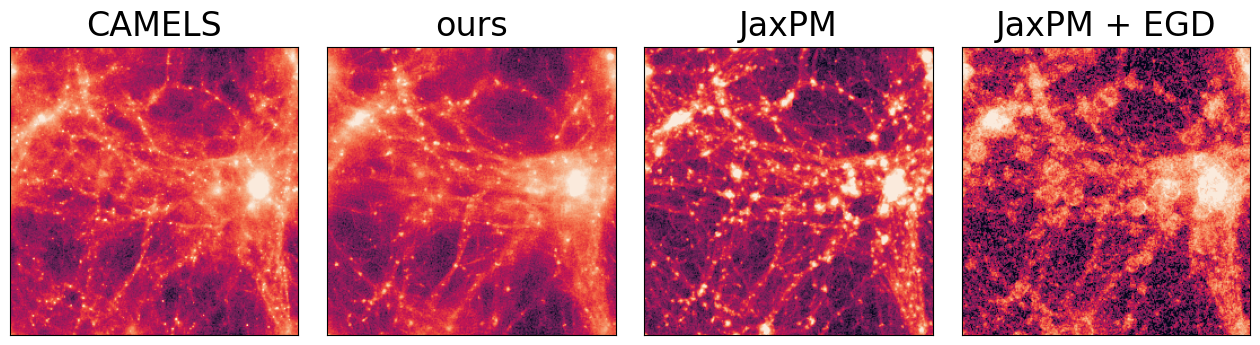

In [11]:
# gas
plot_gas_poss = [ref_gas_pos, hpm_gas_pos, pm_gas_pos, egd_gas_pos]
plot_gas_weights = [
    jnp.full(ref_gas_pos.shape[0], 1),
    jnp.full(hpm_gas_pos.shape[0], 1),
    jnp.full(pm_gas_pos.shape[0], 1),
    jnp.full(egd_gas_pos.shape[0], 1/gas_mass),
]
fig, axs = plot_row(
    plot_gas_poss, 
    0, 
    cmap="rocket", 
    weights=plot_gas_weights,
)
file = f"plots/final_2d_fields_mesh={mesh_per_dim}_gas.pdf"

titles = ["CAMELS", "ours", "JaxPM", "JaxPM + EGD"]
for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=fontsize, pad=8)

fig.savefig(file, bbox_inches="tight", pad_inches=0, dpi=300)

vlim = [2.50, 345.92]


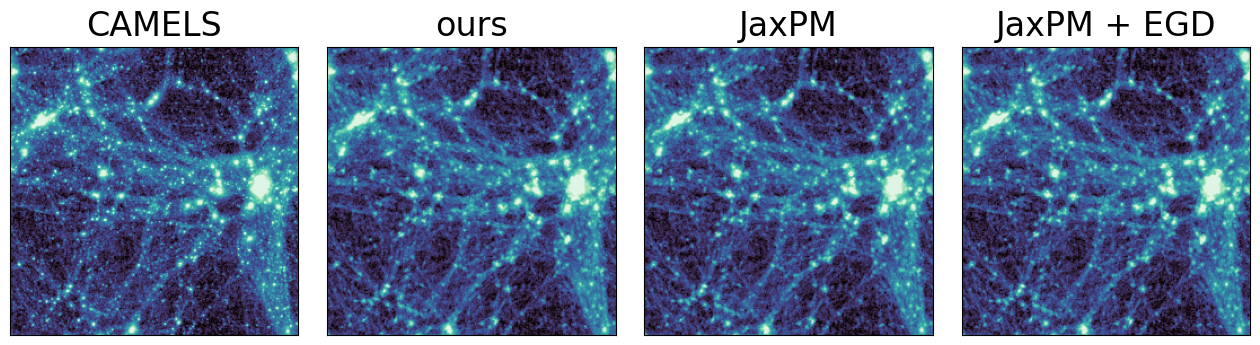

In [12]:
# dark matter
plot_dm_poss = [
    jnp.concat([ref_dm_pos]), 
    jnp.concat([hpm_dm_pos]), 
    jnp.concat([pm_dm_pos]), 
    jnp.concat([egd_dm_pos]), 
]
plot_dm_weights = [
    jnp.full(ref_dm_pos.shape[0], 1),
    jnp.full(hpm_dm_pos.shape[0], 1),
    jnp.full(pm_dm_pos.shape[0], 1),
    jnp.full(egd_dm_pos.shape[0], 1/dm_mass),
]

fig, axs = plot_row(
    plot_dm_poss, 
    0, 
    cmap="mako", 
    weights=plot_dm_weights
)
file = f"plots/final_2d_fields_mesh={mesh_per_dim}_dm.pdf"

titles = ["CAMELS", "ours", "JaxPM", "JaxPM + EGD"]
for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=fontsize, pad=8)

# fig.savefig(file, bbox_inches="tight", pad_inches=0, dpi=300)
fig.savefig(file, bbox_inches="tight", pad_inches=0)

# evolution

In [13]:
i0 = 0
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
t0 = scales[i0]

i_plot = np.linspace(0, 33, 4, dtype=int)
tsave = scales[i_plot]

ref_gas_poss = gas_poss[i_plot]

pm_res = solve_ode(
    y0, t0, tsave, gravity_model=None, pressure_model=None, training=False, nt=1, tstep=scales
)
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res

hpm_res = solve_ode(
    y0, t0, tsave, gravity_model=None, pressure_model=pressure_model, training=False, nt=1, tstep=scales
)
hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res

Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


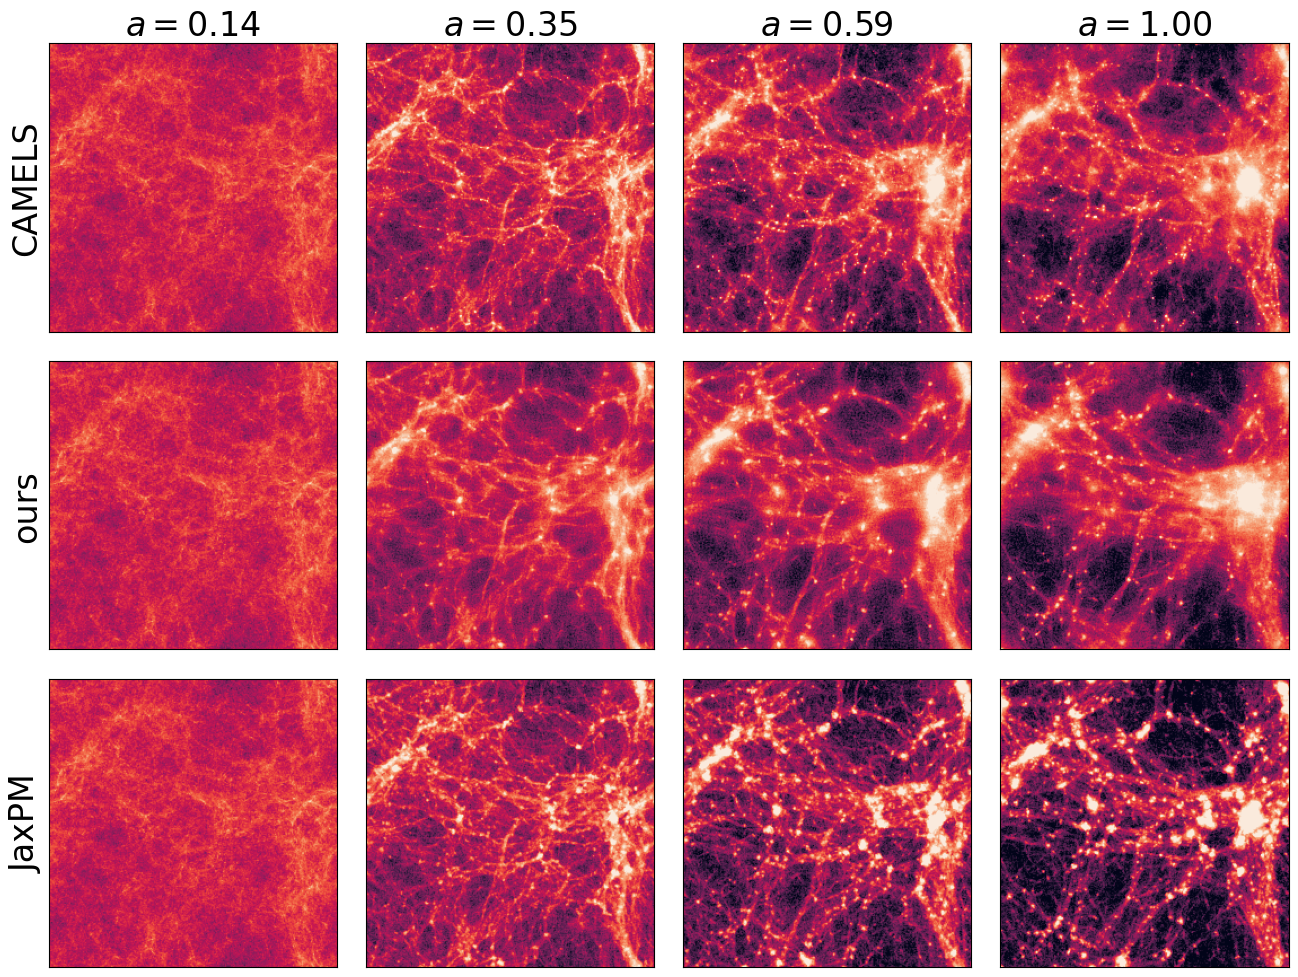

In [14]:
from matplotlib.colors import LogNorm

nrows = 3
ncols = len(i_plot)

poss = [ref_gas_poss, hpm_gas_poss, pm_gas_poss]

plot_mesh = 256
fields = np.zeros((nrows, ncols, plot_mesh, plot_mesh))
empty_mesh = jnp.zeros((plot_mesh,) * 2)
for i in range(nrows):
    for j in range(ncols):
        pos = poss[i][j]
        fields[i,j] = cic_paint_2d(empty_mesh, pos[:,[1,2]] * (plot_mesh // mesh_per_dim))

vmin = np.percentile(fields, 1)
vmax = np.percentile(fields, 99)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(nrows=3, ncols=ncols, figsize=(4*ncols, 4*nrows))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(nrows):
    for j in range(ncols):
        ax[i,j].imshow(fields[i,j], norm=norm, cmap="rocket", interpolation=None)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

ylabels = ["CAMELS", "ours", "JaxPM"]
for i in range(nrows):
    ax[i,0].set_ylabel(ylabel=ylabels[i], fontsize=24)

for j in range(ncols):
    ax[0,j].set_title(r"$a = " + f"{scales[i_plot[j]]:.2f}" + r"$", fontsize=24)

fig.savefig(f"plots/evolution_2d_fields_mesh={mesh_per_dim}_gas.pdf", bbox_inches="tight", pad_inches=0)

# two-point

In [15]:
@jax.jit
def get_pk(pos):
    rho = cic_paint(jnp.zeros(mesh_shape), pos)
    delta = rho / rho.mean() - 1

    k, cls = objectives.power_spectrum(delta)

    return cls

@jax.jit
def get_x(pos_1, pos_2):
    rho_1 = cic_paint(jnp.zeros(mesh_shape), pos_1)
    delta_1 = rho_1 / rho_1.mean() - 1

    rho_2 = cic_paint(jnp.zeros(mesh_shape), pos_2)
    delta_2 = rho_2 / rho_2.mean() - 1

    k, cross = objectives.cross_correlation(delta_1, delta_2)

    return cross


In [16]:
cv_dir = "/pscratch/sd/a/athomsen/flatiron/CAMELS/Sims/SIMBA/CV"
i0 = 0
i1 = -1

all_ref_pk = []
all_pm_pk = []
all_hpm_pk = []
all_egd_pk = []

all_pm_x = []
all_hpm_x = []
all_egd_x = []

for i in tqdm(range(1, 27)):
    sim_file = os.path.join(cv_dir, f"CV_{i}", f"parts={parts_per_dim},mesh={mesh_per_dim}.h5")

    # ref
    with h5py.File(sim_file) as f:
        i_snap = (i0, i1)
        
        scales = f["scales"][:]
        dm_poss = f["dm_poss"][i_snap, ...]
        dm_vels = f["dm_vels"][i_snap, ...]
        gas_poss = f["gas_poss"][i_snap, ...]
        gas_vels = f["gas_vels"][i_snap, ...]

    ref_pos = gas_poss[1]
    ref_pk = get_pk(ref_pos)
    all_ref_pk.append(ref_pk)
        
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    t0 = scales[i0]
    tsave = [scales[i1]]

    # pm
    pm_res = solve_ode(
        y0, 
        t0, 
        tsave, 
        pressure_model=None, 
        training=False, 
        nt=1, 
        tstep=scales
    )

    pm_pos = pm_res[2]
    all_pm_pk.append(get_pk(pm_pos))
    all_pm_x.append(get_x(pm_pos, ref_pos))
    
    pm_dm_pos = pm_res[0]

    # hpm
    hpm_res = solve_ode(
        y0, 
        t0, 
        tsave, 
        pressure_model=pressure_model, 
        training=False, 
        nt=1, 
        tstep=scales
    )
    hpm_pos = hpm_res[2]
    all_hpm_pk.append(get_pk(hpm_pos))
    all_hpm_x.append(get_x(hpm_pos, ref_pos))

    # EGD
    egd_gas_pos, egd_dm_pos, egd_rho_dm, egd_rho_gas, egd_rho_tot = egd.apply_egd_correction(
        egd_params, pm_dm_pos, cosmo, mesh_shape
    )
    all_egd_pk.append(get_pk(egd_gas_pos))
    all_egd_x.append(get_x(egd_gas_pos, ref_pos))

all_ref_pk = jnp.stack(all_ref_pk)
all_pm_pk = jnp.stack(all_pm_pk)
all_hpm_pk = jnp.stack(all_hpm_pk)
all_egd_pk = jnp.stack(all_egd_pk)

all_pm_x = jnp.stack(all_pm_x)
all_hpm_x = jnp.stack(all_hpm_x)
all_egd_x = jnp.stack(all_egd_x)


2025-10-21 07:36:42.783875: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %scatter.141 = f32[65]{0} scatter(%broadcast.11, %constant.34, %constant.36), update_window_dims={1}, inserted_window_dims={}, scatter_dims_to_operand_dims={0}, index_vector_dim=1, to_apply=%region_2.140, metadata={op_name="jit(get_pk)/scatter-add" source_file="/global/u2/a/athomsen/flatiron/JaxPM/jaxpm/utils.py" source_line=72}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-10-21 07:36:46.787131: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 5.003326626s
Constant folding a

Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


2025-10-21 07:36:56.687222: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 2s:

  %scatter.141 = f32[65]{0} scatter(%broadcast.11, %constant.34, %constant.36), update_window_dims={1}, inserted_window_dims={}, scatter_dims_to_operand_dims={0}, index_vector_dim=1, to_apply=%region_2.140, metadata={op_name="jit(get_pk)/scatter-add" source_file="/global/u2/a/athomsen/flatiron/JaxPM/jaxpm/utils.py" source_line=72}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-10-21 07:36:59.682921: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.995786756s
Constant folding a

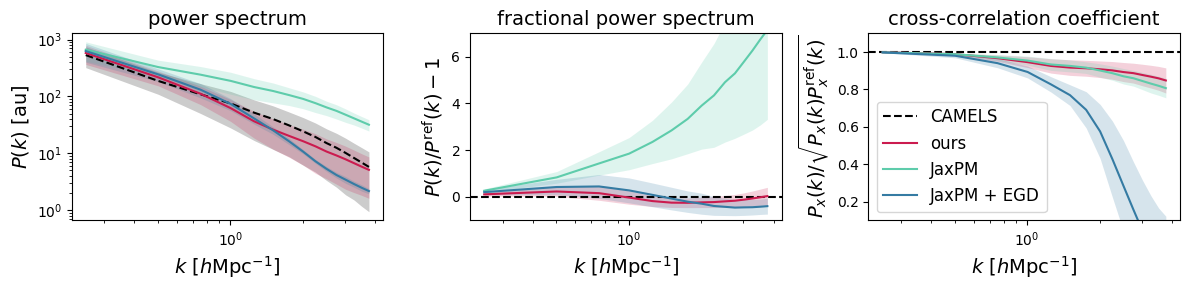

In [17]:
pm_color = "#5eccab" 
hpm_color = sns.color_palette("rocket", 1)[0]
egd_color = sns.color_palette("mako", 1)[0]

xlabel = r"$k$ [$h \text{Mpc}^{-1}$]"
fontsize = 14

# x-axis
rho = cic_paint(jnp.zeros(mesh_shape), ref_pos)
delta = rho / rho.mean() - 1
k, _ = objectives.power_spectrum(delta)
inds = k < 4.0

def plot_band(ax, y, color, linestyle="-", label=None):
    # limit plotting range
    x = k[inds]
    y = y[:,inds]

    mean_y = jnp.mean(y, axis=0)
    std_y = jnp.std(y, axis=0)
    
    ax.plot(x, mean_y, color=color, label=label, linestyle=linestyle)
    ax.fill_between(x, mean_y - std_y, mean_y + std_y, color=color, alpha=0.2, linewidth=0)

fig, ax = plt.subplots(figsize=(12, 3), ncols=3, nrows=1, sharex=True)

plot_band(ax[0], all_ref_pk, color="k", linestyle="--")
plot_band(ax[0], all_hpm_pk, color=hpm_color)
plot_band(ax[0], all_pm_pk, color=pm_color)
plot_band(ax[0], all_egd_pk, color=egd_color)
ax[0].set_xlabel(xlabel, fontsize=fontsize)
ax[0].set_ylabel(r"$P(k)$ [au]", fontsize=fontsize)
ax[0].set_title("power spectrum", fontsize=fontsize)
ax[0].set(xscale="log", yscale="log")

ax[1].axhline(0, color="k", linestyle="--")
plot_band(ax[1], all_hpm_pk / all_ref_pk - 1, color=hpm_color)
plot_band(ax[1], all_pm_pk / all_ref_pk - 1, color=pm_color)
plot_band(ax[1], all_egd_pk / all_ref_pk - 1, color=egd_color)
ax[1].set_xlabel(xlabel, fontsize=fontsize)
ax[1].set_ylabel(r"$P(k)/P^\text{ref}(k) - 1$", fontsize=fontsize)
ax[1].set_title("fractional power spectrum", fontsize=fontsize)
ax[1].set(ylim=(-1, 7))

ax[2].axhline(1, color="k", linestyle="--", label="CAMELS")
plot_band(ax[2], all_hpm_x / jnp.sqrt(all_hpm_pk * all_ref_pk), color=hpm_color, label="ours") 
plot_band(ax[2], all_pm_x / jnp.sqrt(all_pm_pk * all_ref_pk), color=pm_color, label="JaxPM") 
plot_band(ax[2], all_egd_x / jnp.sqrt(all_egd_pk * all_ref_pk), color=egd_color, label="JaxPM + EGD")
ax[2].set_xlabel(xlabel, fontsize=fontsize)
ax[2].set_ylabel(r"$P_x(k) / \sqrt{P_x(k) P_x^\text{ref}(k)}$", fontsize=fontsize)
ax[2].set_title("cross-correlation coefficient", fontsize=fontsize)
ax[2].set(ylim=(0.1, 1.1))
ax[2].legend(loc="lower left", fontsize=fontsize-2)

fig.tight_layout()

fig.savefig(f"plots/final_2pt_mesh={mesh_per_dim}.pdf", bbox_inches="tight", pad_inches=0, dpi=300)